**N-GRAM Mini Proje**

Amaç: Unigram vs Bigram farkını görmek (model gerçekten fark ediyor mu?)

In [2]:
# Gerekli kütüphaneler
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1️⃣ CSV oku
df = pd.read_csv("/content/IMDB Dataset.csv", engine='python')

# 2️⃣ Label encode: positive->1, negative->0
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

# 3️⃣ Küçük dataset (10.000 örnek)
df_small = df.sample(10000, random_state=42)

X = df_small['review']
y = df_small['sentiment']

# 4️⃣ Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 MODEL 1: UNIGRAM
vec_uni = TfidfVectorizer(max_features=5000, ngram_range=(1,1))
X_train_uni = vec_uni.fit_transform(X_train)
X_test_uni = vec_uni.transform(X_test)

model_uni = LogisticRegression(solver='liblinear')
model_uni.fit(X_train_uni, y_train)
pred_uni = model_uni.predict(X_test_uni)

acc_uni = accuracy_score(y_test, pred_uni)

# 🔹 MODEL 2: BIGRAM
vec_bi = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_bi = vec_bi.fit_transform(X_train)
X_test_bi = vec_bi.transform(X_test)

model_bi = LogisticRegression(solver='liblinear')
model_bi.fit(X_train_bi, y_train)
pred_bi = model_bi.predict(X_test_bi)

acc_bi = accuracy_score(y_test, pred_bi)

# 🔹 Sonuçlar
print("Unigram Accuracy:", acc_uni)
print("Bigram Accuracy:", acc_bi)

Unigram Accuracy: 0.876
Bigram Accuracy: 0.872


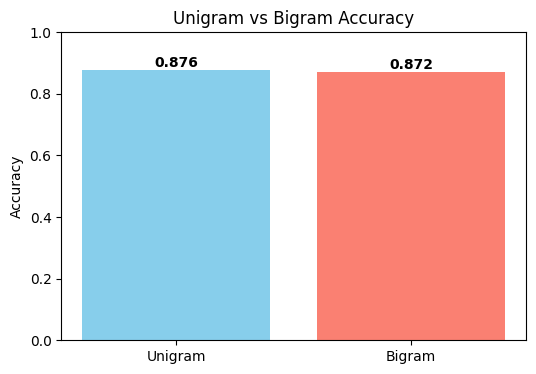

In [4]:
import matplotlib.pyplot as plt

accuracies = [acc_uni, acc_bi]
labels = ['Unigram', 'Bigram']

plt.figure(figsize=(6,4))
plt.bar(labels, accuracies, color=['skyblue','salmon'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Unigram vs Bigram Accuracy")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()